**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of 4 fluorophores](#toc1_)    
  - [Figure](#toc1_1_)    
  - [Reading data](#toc1_2_)    
      - [4 fluorophores](#toc1_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of 4 fluorophores](#toc0_)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

reading_from = (
    r"D:\python_output\Chapter_I\1_13_multi_f_et_adjustments\OET_efficiency_variations"
)

## <a id='toc1_1_'></a>[Figure](#toc0_)

In [3]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    legendtitle,
    xlim2,
    ylim2,
    inset_x_ticks,
    inset_y_ticks,
    colors=colors,
):
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index, fingerprint],
            label=label,
            color=color,
            linestyle="-",
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=15,
        ),
        **description,
    )

    inset = ax.inset_axes([0.51, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index, fingerprint],
            axes=inset,
            label=label,
            color=color,
            linestyle="-",
        )
    inset.set_ylabel("")
    inset.set_xlabel("")
    inset.set_xticks(inset_x_ticks)
    inset.set_yticks(inset_y_ticks)


rcParams["axes.linewidth"] = 2

In [6]:
reading_from_001_1em4 = reading_from + r"\001_1e-4"
reading_from_01_1em4 = reading_from + r"\01_1e-4"
reading_from_1_1em4 = reading_from + r"\1_1e-4"
reading_from_1em4_1 = reading_from + r"\1e-4_1"
reading_from_1em5_1 = reading_from + r"\1e-5_1"
reading_from_1em5_1_only_oet = reading_from + r"\1e-5_1_only_oet"
reading_from_1em5_1_risc = reading_from + r"\1e-5_1_risc"
reading_from_1em6_1 = reading_from + r"\1e-6_1"
reading_from_2em7_1 = reading_from + r"\2e-7_1"

all_folders = [
    reading_from_1_1em4,
    reading_from_01_1em4,
    reading_from_1em4_1,
    reading_from_1em5_1,
    reading_from_1em6_1,
    reading_from_2em7_1,
    reading_from_1em5_1_only_oet,
    reading_from_1em5_1_risc,
]

titles = [
    r"$k_{OET} \cdot 1, \eta = 10^{-4}$",
    r"$k_{OET} \cdot 0.1, \eta = 10^{-4}$",
    r"$k_{OET} \cdot 10^{-4}, \eta = 1$",
    r"$k_{OET} \cdot 10^{-5}, \eta = 1$",
    r"$k_{OET} \cdot 10^{-6}, \eta = 1$",
    r"$k_{OET} \cdot 2 \cdot 10^{-7}, \eta = 1$",
    r"$k_{OET} \cdot 10^{-5}, \eta = 1, \text{only OET}$",
    r"$k_{OET} \cdot 10^{-5}, \eta = 1, \text{RISC}$",
]

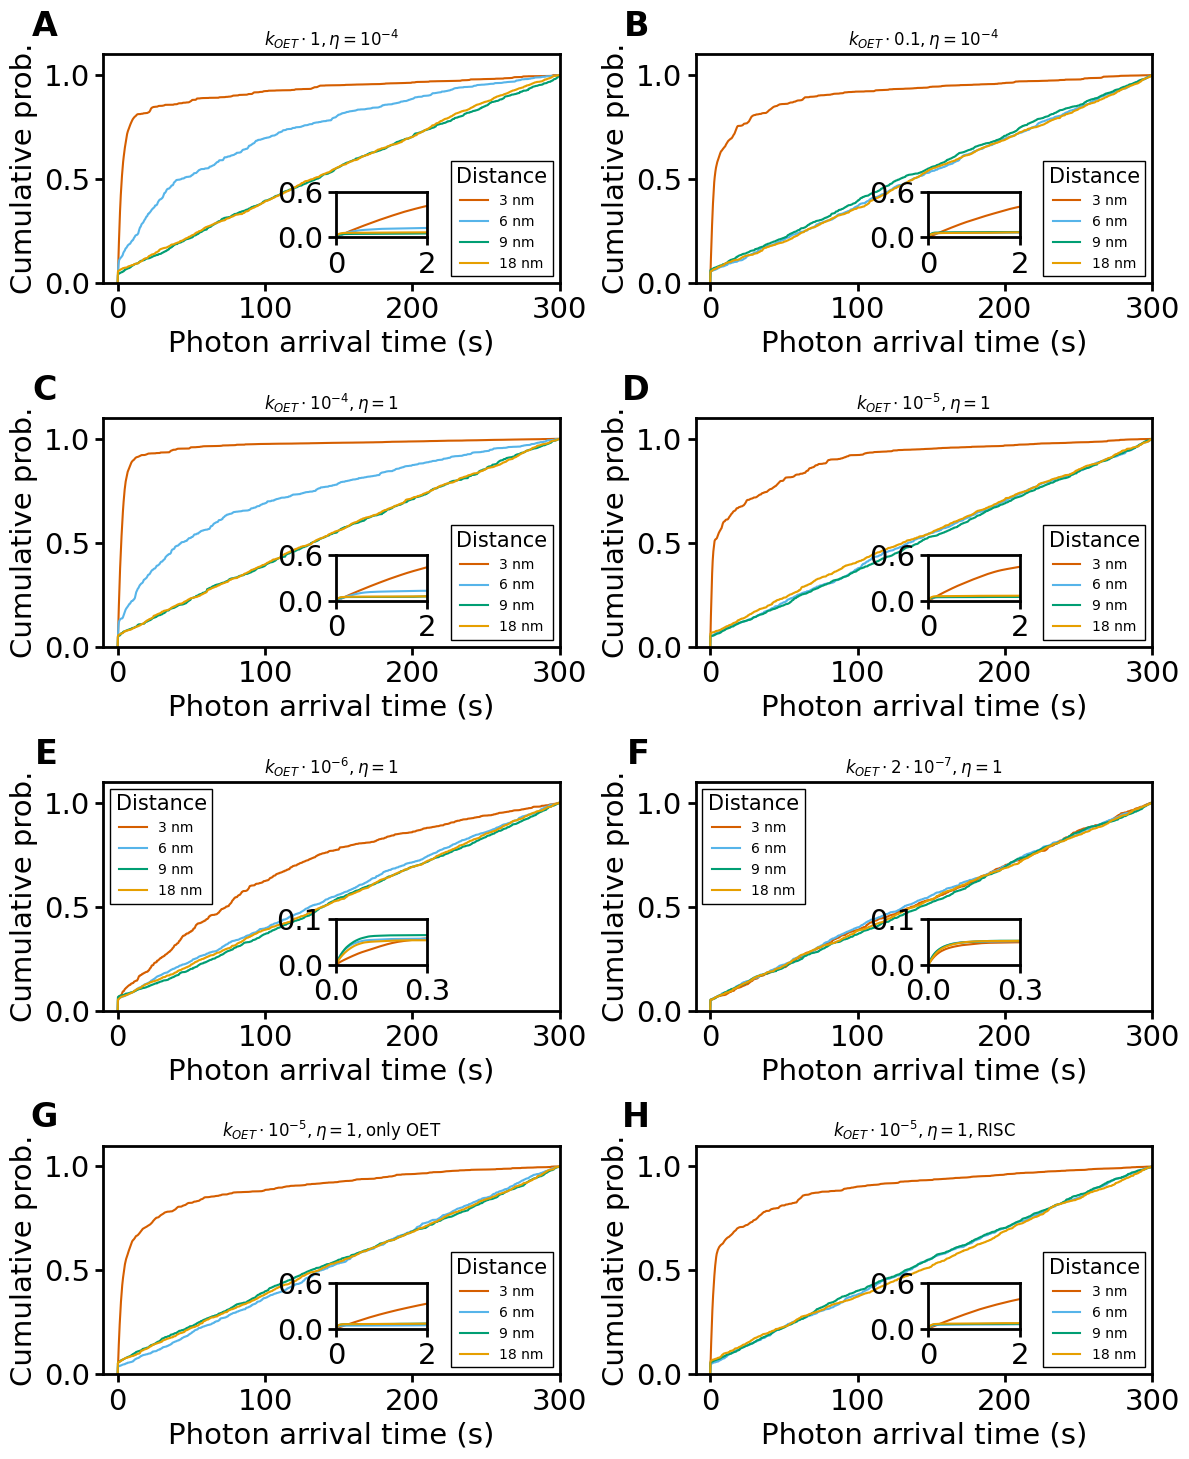

: 

In [ ]:
identifiers = [
    "3nm",
    "6nm",
    "9nm",
    "18nm",
]

gs = plt.GridSpec(4, 2)
fig = plt.figure(figsize=(12, 14.7))

for j, (folder, title) in enumerate(zip(all_folders, titles)):
    fingerprints_all = []
    for i, id in enumerate(identifiers):
        fingerprints_all.append(
            pd.Series(
                np.zeros(300001),
                np.round(np.linspace(0, 300, 300001), decimals=12),
                dtype=np.int32,
            )
        )
        for file in Path(folder).iterdir():
            if file.suffix == ".parquet" and id in file.name:
                data = pd.read_parquet(file)
                non_zero = data[data > 0].values.flatten()
                non_zero = non_zero[~np.isnan(non_zero)]
                fingerprints_all[i] += data.sum(axis=1)
        fingerprint = fingerprints_all[i].cumsum() / fingerprints_all[i].sum()
        fingerprints_all[i] = fingerprint

    labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
    legendtitle1 = "Distance"
    ax = fig.add_subplot(gs[j // 2, j % 2])
    if j in [4, 5]:
        plot_figure3(
            ax, labels1, fingerprints_all, legendtitle1, 0.3, 0.1, [0, 0.3], [0, 0.1]
        )
    else:
        plot_figure3(
            ax, labels1, fingerprints_all, legendtitle1, 2, 0.6, [0, 2], [0, 0.6]
        )
    ax.set_title(title)
axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H"]):
    axis.text(
        -0.1,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
fig.savefig(
    reading_from + r"\OET_efficiency_variations.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)